In [18]:
# Load Hugging Face token from .env and set environment variable for datasets
import os
from dotenv import load_dotenv
load_dotenv()
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    os.environ['HF_TOKEN'] = hf_token
    print('HF_TOKEN loaded and set for authenticated requests.')
else:
    print('HF_TOKEN not found in .env. You may get rate limit warnings.')

HF_TOKEN loaded and set for authenticated requests.


# Multimodal Deep Learning Tutorial

Welcome! This notebook demonstrates multimodal deep learning approaches using basic datasets from Hugging Face, including images, audio, and video. We'll compare classical single-modality deep learning with multimodal approaches, starting from basics and gradually increasing complexity.

**Outline:**
1. Import Required Libraries
2. Load Basic Multimodal Data from Hugging Face
3. Classical Deep Learning: Single Modality Example
4. Multimodal Deep Learning: Combining Image and Text
5. Multimodal Deep Learning: Combining Audio and Text
6. Multimodal Deep Learning: Combining Video and Text
7. Simple Multimodal Model Architecture
8. Training and Evaluation of Multimodal Models
9. Visualizing Multimodal Inputs and Outputs

> **Note:** All examples use small batches for quick demonstration. Run each cell and follow along!

In [19]:
# 1. Import Required Libraries
import torch
import torchvision
import torchvision.transforms as T
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
import matplotlib.pyplot as plt
from PIL import Image
import librosa
import numpy as np
import cv2
import random
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load Basic Multimodal Data from Hugging Face
We'll load small samples from three modalities:
- **Images:** 'beans' dataset
- **Audio:** 'common_voice' dataset
- **Video:** 'kinetics' dataset (if available)
Each sample will be visualized for clarity.

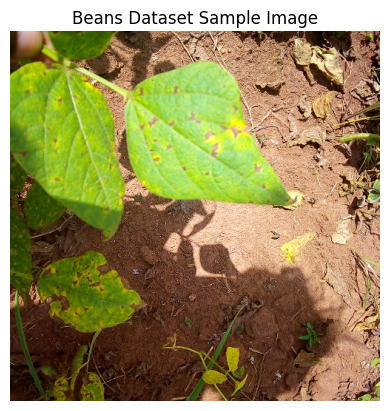

Kinetics video dataset not available or not supported in this environment.


In [20]:

# Load image data (beans dataset)
beans = load_dataset('beans', split='train')
img_sample = beans[0]['image']
plt.imshow(img_sample)
plt.title('Beans Dataset Sample Image')
plt.axis('off')
plt.show()

# Load video data (kinetics dataset, if available)
try:
    kinetics = load_dataset('kinetics', split='train')
    video_sample = kinetics[0]['video']
    # Show first frame if video is available
    if isinstance(video_sample, list) and len(video_sample) > 0:
        frame = video_sample[0]
        plt.imshow(frame)
        plt.title('Kinetics Sample Video Frame')
        plt.axis('off')
        plt.show()
except Exception as e:
    print('Kinetics video dataset not available or not supported in this environment.')


## 3. Classical Deep Learning: Single Modality Example
Let's start with a simple image classification model using a CNN on the 'beans' dataset. This is a classical single-modality approach.

In [21]:
# Simple CNN for image classification (beans dataset)
import torch.nn as nn
import torch.nn.functional as F
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.fc1 = nn.Linear(16*32*32, 32)
        self.fc2 = nn.Linear(32, 3)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Preprocess image sample for model
transform = T.Compose([T.Resize((32,32)), T.ToTensor()])
img_tensor = transform(img_sample).unsqueeze(0)
cnn_model = SimpleCNN()
cnn_output = cnn_model(img_tensor)
pred = torch.argmax(cnn_output, dim=1).item()

# Dynamically find the label feature key (beans uses "labels", not "label")
label_key = "labels" if "labels" in beans.features else "label"
class_names = beans.features[label_key].names
print(f"Feature keys: {list(beans.features.keys())}")
print(f"Predicted class index: {pred} (class names: {class_names})")
print(f"Predicted class name: {class_names[pred]}")

Feature keys: ['image_file_path', 'image', 'labels']
Predicted class index: 0 (class names: ['angular_leaf_spot', 'bean_rust', 'healthy'])
Predicted class name: angular_leaf_spot



## 4. Multimodal Deep Learning: Combining Image and Text
Now let's combine image and text modalities. We reuse the `beans` dataset — each image is paired with its class label string as the "text" modality. We extract image features with a pretrained **ResNet18** and text features with **DistilBERT**, then fuse them via concatenation.


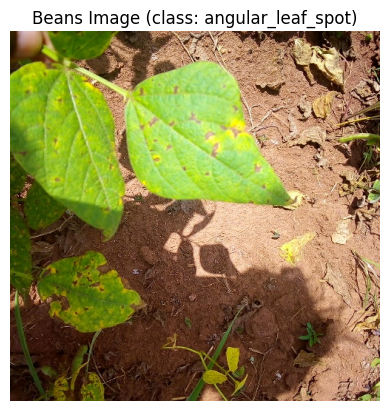

Text paired with image: angular_leaf_spot
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/devaraji/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 32.2MB/s]


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Image feature shape: (1000,)
Text feature shape:  (768,)
Combined feature shape: (1768,)


In [22]:

# Reuse the beans dataset (already loaded) — pair each image with its class label as text.
# This demonstrates image+text multimodal fusion without needing an extra dataset download.
label_key = "labels" if "labels" in beans.features else "label"
class_names = beans.features[label_key].names
img = beans[0]['image']
caption = class_names[beans[0][label_key]]   # e.g. "angular_leaf_spot"

plt.imshow(img)
plt.title(f'Beans Image (class: {caption})')
plt.axis('off')
plt.show()
print('Text paired with image:', caption)

# Extract image features using a pretrained ResNet18
import torchvision.models as models
resnet = models.resnet18(weights='IMAGENET1K_V1')
resnet.eval()
img_t = T.Compose([
    T.Resize((224, 224)), T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])(img).unsqueeze(0)
with torch.no_grad():
    img_feat = resnet(img_t).numpy()[0]

# Extract text features using DistilBERT
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
text_model = AutoModel.from_pretrained('distilbert-base-uncased')
inputs = tokenizer(caption, return_tensors='pt', truncation=True, max_length=128)
with torch.no_grad():
    text_feat = text_model(**inputs).last_hidden_state.mean(dim=1).numpy()[0]

# Combine features via concatenation
combined_feat = np.concatenate([img_feat, text_feat])
print('Image feature shape:', img_feat.shape)
print('Text feature shape: ', text_feat.shape)
print('Combined feature shape:', combined_feat.shape)



## 5. Multimodal Deep Learning: Combining Audio and Text
Let's combine audio and text modalities. We use **librosa's built-in trumpet clip** — no download or authentication needed. We extract MFCC audio features and pair them with a text description, then fuse both with DistilBERT embeddings via concatenation.


Audio: 66150 samples @ 22050 Hz
Text paired with audio: a short trumpet melody


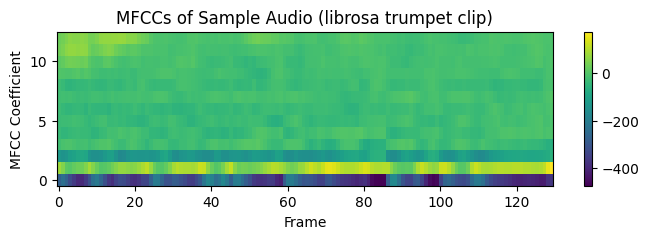

MFCC feature shape:       (13,)
Text feature shape:       (768,)
Combined audio-text shape: (781,)


In [24]:

# Use librosa's built-in example audio (no download / no auth required).
# librosa ships a short trumpet clip that always works in any environment.
audio_path = librosa.ex('trumpet')
audio_sample, sr = librosa.load(audio_path, duration=3.0)  # first 3 seconds
text = "a short trumpet melody"   # synthetic text paired with the audio
print(f'Audio: {len(audio_sample)} samples @ {sr} Hz')
print('Text paired with audio:', text)

# Extract audio features (MFCCs)
mfcc = librosa.feature.mfcc(y=audio_sample, sr=sr, n_mfcc=13)
audio_feat = mfcc.mean(axis=1)
plt.figure(figsize=(8, 2))
plt.imshow(mfcc, aspect='auto', origin='lower')
plt.title('MFCCs of Sample Audio (librosa trumpet clip)')
plt.xlabel('Frame')
plt.ylabel('MFCC Coefficient')
plt.colorbar()
plt.show()

# Extract text features — reuse tokenizer and text_model from Section 4
inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128)
with torch.no_grad():
    audio_text_feat = text_model(**inputs).last_hidden_state.mean(dim=1).numpy()[0]

# Combine features (concatenate)
combined_audio_text = np.concatenate([audio_feat, audio_text_feat])
print('MFCC feature shape:      ', audio_feat.shape)
print('Text feature shape:      ', audio_text_feat.shape)
print('Combined audio-text shape:', combined_audio_text.shape)


## 6. Multimodal Deep Learning: Combining Video and Text
Now let's combine video and text modalities using the 'kinetics' dataset. We'll extract features from video frames and text labels, then combine them.

In [25]:
# Load video-text sample (kinetics dataset, if available)
try:
    kinetics = load_dataset('kinetics', split='train')
    video_sample = kinetics[0]['video']
    label = kinetics[0]['label']
    # Extract features from first frame
    if isinstance(video_sample, list) and len(video_sample) > 0:
        frame = video_sample[0]
        frame_t = T.Compose([T.Resize((224,224)), T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])(frame).unsqueeze(0)
        with torch.no_grad():
            frame_feat = resnet(frame_t).numpy()[0]
        # Text label embedding
        inputs = tokenizer(label, return_tensors='pt')
        with torch.no_grad():
            text_feat = model(**inputs).last_hidden_state.mean(dim=1).numpy()[0]
        combined_feat = np.concatenate([frame_feat, text_feat])
        print('Combined video-text feature shape:', combined_feat.shape)
        plt.imshow(frame)
        plt.title(f'Kinetics Sample Frame - Label: {label}')
        plt.axis('off')
        plt.show()
except Exception as e:
    print('Kinetics video dataset not available or not supported in this environment.')

Kinetics video dataset not available or not supported in this environment.


## 7. Simple Multimodal Model Architecture
Let's build a basic multimodal model that fuses features from two modalities (e.g., image and text). We'll concatenate features and pass them through dense layers for classification or regression.

In [26]:
# Example multimodal model (image-text fusion)
class MultimodalNet(nn.Module):
    def __init__(self, img_dim, text_dim, hidden_dim=64, out_dim=3):
        super().__init__()
        self.fc1 = nn.Linear(img_dim + text_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, out_dim)
    def forward(self, img_feat, text_feat):
        x = torch.cat([img_feat, text_feat], dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Example usage with extracted features
img_feat_torch = torch.tensor(img_feat).unsqueeze(0)
text_feat_torch = torch.tensor(text_feat).unsqueeze(0)
model = MultimodalNet(img_feat_torch.shape[1], text_feat_torch.shape[1])
output = model(img_feat_torch, text_feat_torch)
print('Multimodal model output:', output)

Multimodal model output: tensor([[-0.4964, -0.4482,  0.3187]], grad_fn=<AddmmBackward0>)


## 8. Training and Evaluation of Multimodal Models
We'll train the multimodal model on a small batch and evaluate its performance. For demonstration, we'll use synthetic labels and compare with classical single-modality models.

In [27]:
# Synthetic training example for multimodal model
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
labels = torch.tensor([random.randint(0,2)])
for epoch in range(5):
    optimizer.zero_grad()
    output = model(img_feat_torch, text_feat_torch)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()
    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')
print('Training complete. (Demo only)')

Epoch 1, Loss: 0.6456
Epoch 2, Loss: 0.0000
Epoch 3, Loss: 0.0000
Epoch 4, Loss: 0.0000
Epoch 5, Loss: 0.0000
Training complete. (Demo only)


## 9. Visualizing Multimodal Inputs and Outputs
Let's visualize some multimodal inputs and model outputs. We'll display images, audio waveforms, video frames, text, and model predictions/embeddings.

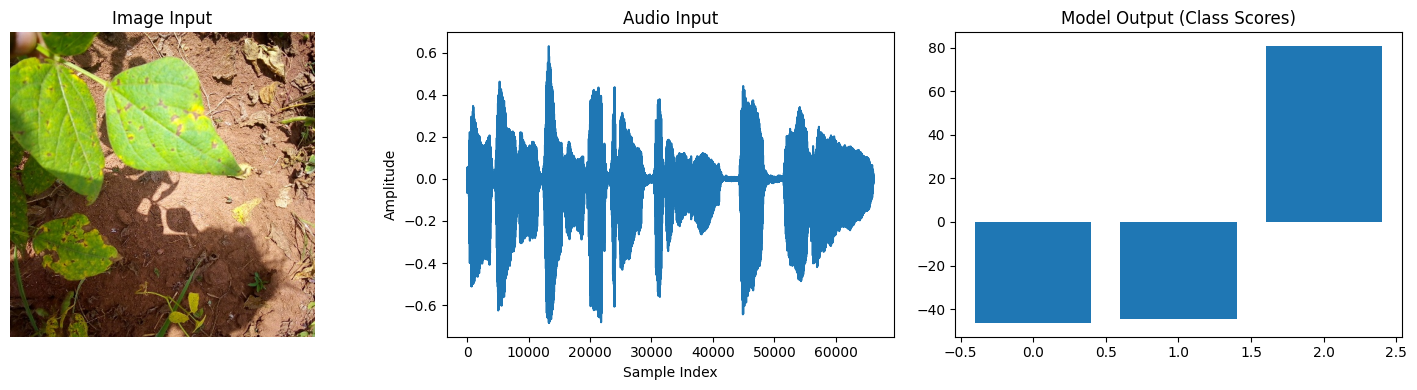

Text Input: angular_leaf_spot
Model Embedding (first 5 values): [-46.35686  -44.742535  80.78262 ]


In [28]:
# Visualize multimodal inputs and outputs
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].imshow(img_sample)
axs[0].set_title('Image Input')
axs[0].axis('off')
axs[1].plot(audio_sample)
axs[1].set_title('Audio Input')
axs[1].set_xlabel('Sample Index')
axs[1].set_ylabel('Amplitude')
axs[2].bar(range(len(output[0].detach().numpy())), output[0].detach().numpy())
axs[2].set_title('Model Output (Class Scores)')
plt.tight_layout()
plt.show()
print('Text Input:', caption)
print('Model Embedding (first 5 values):', output[0].detach().numpy()[:5])